# Texas Childcare: Compliance Records vs. Family Experience
## Notebook 02 — Model 2A: Center-Level Review Text

**Author:** Rakesh Chandrasekaran
**Program:** Professional Certificate in ML and AI, UC Berkeley
**Date:** June 2026

---

## Research Question

**Do Texas HHSC compliance records and families' Google reviews agree on which daycare centers are high quality — and can a parent rely on compliance records alone to make an informed childcare decision?**

This project builds two predictive models. The first uses HHSC regulatory inspection features; the second uses the text of families' own Google reviews. Both models predict a center's Google star rating — both the exact rating (regression) and whether a center is rated excellent by families (4.5 stars and above, classification). Comparing the two models reveals how closely compliance data and family experience track each other, and whether a parent consulting only inspection records would reach the same conclusion as one who reads reviews.


---

## Cities in Scope
Austin · Houston · San Antonio · Dallas · Fort Worth

---

### This Notebook
Trains and evaluates TF-IDF + Ridge (regression) and TF-IDF + Logistic Regression (classification) on center-level aggregated review text. XGBoost is tested as a comparison for both tasks to confirm linear models are sufficient. Uses the same train/test split and evaluation metrics as Model 1 for a direct compliance-vs-text comparison. Saves outputs to `model2a_outputs.pkl`.

### Notebook Structure
0. Setup and Data Loading
    - Imports, constants
    - Load model1_dataset.csv and model2_reviews.csv
    - Load model1_outputs.pkl
    - Check: confirm all Notebook 01 inputs available
1. Model 2A — Algorithm Rationale
2. Model 2A — Center-Level Text (Regression)
    - 2.1 Data Setup — Aggregate reviews per center, apply train/test split
    - 2.2 TF-IDF + Ridge Regression (grid search)
    - 2.3 TF-IDF + XGBoost Regression (comparison model)
        - 2.3.1 Grid Search — Round 1
        - 2.3.2 Grid Search — Round 1 Check Results
    - 2.4 Regression Comparison
    - 2.5 Grid Search Inference
    - 2.6 Test Set Evaluation
    - 2.7 Predicted vs Actual Plot
    - 2.8 Regression Comparison Plot
3. Model 2A — Center-Level Text (Classification)
    - 3.1 Classification Setup
    - 3.2 TF-IDF + Logistic Regression (iterative grid search, 3 rounds)
        - 3.2.1 Pipeline Definition
        - 3.2.2–3.2.7 Grid Search Rounds 1–3 and Check Results
        - 3.2.8 Grid Search Inference
        - 3.2.9 Test Set Evaluation
        - 3.2.10 Inference
        - 3.2.11 Word Coefficients
    - 3.3 TF-IDF + XGBoost Classification (comparison model, 3 rounds)
        - 3.3.1–3.3.6 Grid Search Rounds 1–3 and Check Results
        - 3.3.7 Grid Search Inference
        - 3.3.8 Test Set Evaluation
    - 3.4 TF-IDF + LR vs TF-IDF + XGBoost Classification Comparison
    - 3.5 ROC Curve Overlay
    - 3.6 Classification Comparison Plot
4. Model 2A — Results Summary
    - Regression and classification results vs Model 1
5. Save Outputs — Handoff to Notebooks 03, 04
    - Saves model2a_outputs.pkl

## 0. Setup and Data Loading

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────
import os, pickle
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Visualisation ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

# ── Scikit-learn: pipelines, model selection, metrics ───────────────────
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

# ── XGBoost ───────────────────────────────────────────────────────────────
from xgboost import XGBRegressor, XGBClassifier

# ── Reproducibility and paths ─────────────────────────────────────────────
SEED         = 42
np.random.seed(SEED)
THRESHOLD    = 4.5   # center-level: google_rating >= 4.5 = HIGH_RATED
M2_THRESHOLD = 4     # individual review: review_rating >= 4 (used in Notebook 03)

# ── Directory configuration ───────────────────────────────────────────────
BASE_DIR  = os.getcwd()
IMAGE_DIR = os.path.join(BASE_DIR, "images", "models")
os.makedirs(IMAGE_DIR, exist_ok=True)
PROC_DIR  = os.path.join(BASE_DIR, "data", "processed")

# ── Load datasets (exported by Notebook 00, Section 13.1) ─────────────────
df_model1 = pd.read_csv(os.path.join(PROC_DIR, "model1_dataset.csv"))
df_model2 = pd.read_csv(os.path.join(PROC_DIR, "model2_reviews.csv"))

# ── Load Model 1 outputs (exported by Notebook 01, Section 4) ─────────────
with open(os.path.join(PROC_DIR, "model1_outputs.pkl"), "rb") as f:
    m1 = pickle.load(f)
rmse_xgb=m1["rmse_xgb"]; r2_xgb=m1["r2_xgb"]; m1_auc=m1["m1_auc"]
rmse_ridge=m1["rmse_ridge"]; r2_ridge=m1["r2_ridge"]
y1_pred_prob=m1["y1_pred_prob"]; y1_clf_test=m1["y1_clf_test"]

print(f"Datasets loaded: {len(df_model1):,} centers | {len(df_model2):,} reviews")
print(f"Model 1 results: RMSE={rmse_xgb:.4f}  AUC={m1_auc:.4f}")

Datasets loaded: 1,697 centers | 7,550 reviews
Model 1 results: RMSE=0.5555  AUC=0.6441


In [2]:
# Pre-flight check — confirm all Notebook 01 inputs are available before running models
required_pkl_keys = ["rmse_xgb", "r2_xgb", "m1_auc", "y1_pred_prob",
                     "y1_clf_test", "train_op_ids", "test_op_ids"]
required_frames   = {"df_model1": df_model1, "df_model2": df_model2}

for key in required_pkl_keys:
    status = "OK" if key in m1 else "MISSING"
    print(f"  m1['{key}']  {status}")
for name, df in required_frames.items():
    print(f"  {name:<15} OK  {len(df):,} rows")

  m1['rmse_xgb']  OK
  m1['r2_xgb']  OK
  m1['m1_auc']  OK
  m1['y1_pred_prob']  OK
  m1['y1_clf_test']  OK
  m1['train_op_ids']  OK
  m1['test_op_ids']  OK
  df_model1       OK  1,697 rows
  df_model2       OK  7,550 rows


## 1. Model 2A — Center-Level Text - Algorithm Rationale

**Algorithm Rationale: TF-IDF + Ridge and TF-IDF + Logistic Regression**

Model 2A answers the same research question as Model 1 but uses a different input: the text families wrote in their Google reviews, rather than HHSC compliance records.

**Why TF-IDF.** Reviews are raw text. TF-IDF converts words and bigrams into numeric features, weighting terms that are distinctive to a center relative to the full review corpus. This allows standard regression and classification models to operate directly on review language.

**Why Ridge for regression.** Ridge assigns a coefficient to every word in the vocabulary. Positive coefficients correspond to words associated with high ratings; negative coefficients correspond to words associated with low ratings. This word-level interpretability enables the voice-of-customer analysis. Section 1.3 empirically tests TF-IDF + XGBoost as a comparison. Ridge outperforms it, confirming that linear models generalise better than tree-based models on high-dimensional sparse TF-IDF features.

**Why Logistic Regression for classification.** The same interpretability argument applies to the classification task. Word-level coefficients identify which terms most strongly predict HIGH_RATED versus LOW_RATED centers, enabling a direct comparison with Model 1's SHAP feature analysis in Notebook 01. Section 1.5 empirically tests TF-IDF + XGBoost classification as a comparison to confirm whether Logistic Regression holds its advantage for this task as well.

Both regression and classification use the same center split as Model 1. A Pipeline ensures TF-IDF is fitted only on training data, preventing leakage.

## 2. Model 2A — Center-Level Text (Regression)

Aggregates all reviews per center into one document. Two regression models are compared: TF-IDF + Ridge (interpretable word coefficients) and TF-IDF + XGBoost (captures non-linear word interactions). Results are compared directly to each other and to the Model 1 XGBoost regression baseline.


### 2.1 Model 2A — Data Setup: Aggregate Reviews per Center


In [28]:
# Concatenate all reviews per center into one document so TF-IDF operates at center level
# — matching the granularity of the regression target (aggregate google_rating per center)
reviews_agg = (
    df_model2.groupby('OPERATION_ID')['review_text']
    .apply(lambda texts: ' '.join(texts.fillna('')))
    .reset_index()
    .rename(columns={'review_text': 'agg_text'})
)

# model1_dataset.csv has 1,697 unique centers (no duplicates after Section 8 aggregation)
df_m2a = df_model1[['OPERATION_ID', 'google_rating', 'google_review_count']].merge(
    reviews_agg, on='OPERATION_ID', how='inner'
)

# Load guaranteed-identical split from Notebook 01 pkl — prevents silent mismatch
train_op_ids = set(m1["train_op_ids"])
test_op_ids  = set(m1["test_op_ids"])

m2a_train = df_m2a[df_m2a['OPERATION_ID'].isin(train_op_ids)]
m2a_test  = df_m2a[df_m2a['OPERATION_ID'].isin(test_op_ids)]

X2a_train = m2a_train['agg_text']
X2a_test  = m2a_test['agg_text']
y2a_train = m2a_train['google_rating']
y2a_test  = m2a_test['google_rating']

print(f'Model 2A — Center-Level Regression')
print(f'Train: {len(X2a_train):,} centers | Test: {len(X2a_test):,} centers')
print(f'Note: some Model 1 centers have no reviews — excluded from Model 2A (inner join)')
print(f'Target: google_rating (continuous aggregate, same as Model 1)')

# Design Decision 3: sample weights — same formula as Model 1
# Applied to both Model 1 and Model 2A for methodologically consistent comparison
sw2a_train = (m2a_train['google_review_count'].clip(upper=10) / 10).values
print(f"Model 2A sample weight range: {sw2a_train.min():.2f} – {sw2a_train.max():.2f} | mean: {sw2a_train.mean():.2f}")

Model 2A — Center-Level Regression
Train: 1,327 centers | Test: 333 centers
Note: some Model 1 centers have no reviews — excluded from Model 2A (inner join)
Target: google_rating (continuous aggregate, same as Model 1)
Model 2A sample weight range: 0.10 – 1.00 | mean: 0.88


### 2.2 Model 2A.1 — TF-IDF + Ridge Regression

In [29]:
# TF-IDF + Ridge Regression — interpretable word coefficients for voice-of-customer analysis
# max_features tuned jointly with alpha — unrestricted vocabulary (None) may outperform fixed sizes
m2a_pipeline_ridge = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('model', Ridge())
])
m2a_param_grid_ridge = {
    'tfidf__max_features': [5000, 10000, 20000, None],
    'model__alpha':        [0.1, 1.0, 2.0, 10.0, 100.0]
}
# 4 x 5 = 20 combinations x 5-fold CV = 100 fits
m2a_grid_ridge = GridSearchCV(m2a_pipeline_ridge, m2a_param_grid_ridge,
                               cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
m2a_grid_ridge.fit(X2a_train, y2a_train, model__sample_weight=sw2a_train)
y2a_pred_ridge = m2a_grid_ridge.best_estimator_.predict(X2a_test)
rmse_m2a_ridge = np.sqrt(mean_squared_error(y2a_test, y2a_pred_ridge))
r2_m2a_ridge   = r2_score(y2a_test, y2a_pred_ridge)
print(f"Ridge — best alpha: {m2a_grid_ridge.best_params_}  RMSE={rmse_m2a_ridge:.4f}  R²={r2_m2a_ridge:.4f}")


Ridge — best alpha: {'model__alpha': 0.1, 'tfidf__max_features': None}  RMSE=0.4477  R²=0.3901


### 2.3 Model 2A.1 — TF-IDF + XGBoost Regression

#### 2.3.1 Model 2A.1 — TF-IDF + XGBoost Regression - Grid Search - Round 1

In [39]:
# TF-IDF + XGBoost — comparison model; trees on TF-IDF rarely outperform linear models
# but worth testing to confirm the linear approach is sufficient for this text data
m2a_pipeline_xgb = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=SEED, verbosity=0))
])
# max_features tuned jointly with XGBoost params for a fair comparison with Ridge
m2a_param_grid_xgb = {
    'tfidf__max_features':  [5000, 10000, 20000, None],
    'model__max_depth':     [3, 4, 5],
    'model__learning_rate': [0.05, 0.1, 0.3],
    'model__n_estimators':  [100, 200]
}
# 4 x 3 x 3 x 2 = 72 combinations x 5-fold CV = 360 fits
m2a_grid_xgb = GridSearchCV(m2a_pipeline_xgb, m2a_param_grid_xgb,
                             cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
m2a_grid_xgb.fit(X2a_train, y2a_train, model__sample_weight=sw2a_train)
y2a_pred_xgb = m2a_grid_xgb.best_estimator_.predict(X2a_test)
rmse_m2a_xgb = np.sqrt(mean_squared_error(y2a_test, y2a_pred_xgb))
r2_m2a_xgb   = r2_score(y2a_test, y2a_pred_xgb)
print(f"XGBoost — best params: {m2a_grid_xgb.best_params_}  RMSE={rmse_m2a_xgb:.4f}  R²={r2_m2a_xgb:.4f}")


XGBoost — best params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'tfidf__max_features': 20000}  RMSE=0.4989  R²=0.2426


#### 2.3.2 Model 2A.1 — TF-IDF + XGBoost Regression — Grid Search Round 1 — Check Results

In [ ]:
# Check: are best params at boundary? CV RMSE range indicates landscape flatness
FLAT_THRESHOLD = 0.002
best_cv_rmse_xgb = -m2a_grid_xgb.best_score_
print(f"Round 1 best CV RMSE (XGBoost): {best_cv_rmse_xgb:.4f}")
print(f"Round 1 best params           : {m2a_grid_xgb.best_params_}")
print(f"Ridge best CV RMSE            : {-m2a_grid_ridge.best_score_:.4f}")

top5 = (pd.DataFrame(m2a_grid_xgb.cv_results_)
        .nsmallest(5, "rank_test_score")
        .assign(**{"CV RMSE": lambda d: (-d["mean_test_score"]).round(4),
                   "CV Std" : lambda d:   d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_model__max_depth",
          "param_model__learning_rate", "param_model__n_estimators", "CV RMSE", "CV Std"]])
display(top5)
rmse_range = top5["CV RMSE"].max() - top5["CV RMSE"].min()
decision = "STOP" if rmse_range < FLAT_THRESHOLD else "CONTINUE"
print(f"CV RMSE range: {rmse_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")


Round 1 best CV RMSE (XGBoost): 0.4763
Round 1 best params           : {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'tfidf__max_features': 20000}
Ridge best CV RMSE            : 0.4520


,param_tfidf__max_features,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV RMSE,CV Std
38,20000,4,0.10,200,0.4763,0.0500
22,20000,5,0.05,200,0.4773,0.0485
20,5000,5,0.05,200,0.4777,0.0418
37,10000,4,0.10,200,0.4778,0.0490
46,20000,5,0.10,200,0.4782,0.0507


CV RMSE range: 0.0019 (threshold=0.002) -> STOP


### 2.4 Model 2A.1 — TF-IDF + Ridge vs TF-IDF + XGBoost Regression Comparison

In [37]:
# Select the better model for downstream Notebook 04 comparison
if rmse_m2a_ridge <= rmse_m2a_xgb:
    y2a_pred, rmse_m2a, r2_m2a, m2a_winner = y2a_pred_ridge, rmse_m2a_ridge, r2_m2a_ridge, "TF-IDF + Ridge"
else:
    y2a_pred, rmse_m2a, r2_m2a, m2a_winner = y2a_pred_xgb, rmse_m2a_xgb, r2_m2a_xgb, "TF-IDF + XGBoost"
print(f"Model 2A primary model: {m2a_winner}  (RMSE={rmse_m2a:.4f}  R²={r2_m2a:.4f})")


Model 2A primary model: TF-IDF + Ridge  (RMSE=0.4477  R²=0.3901)


### 2.5 Model 2A.1 — Grid Search Inference

**TF-IDF + Ridge (primary Model 2A).** A single-round GridSearchCV over 20 combinations (`max_features` × `alpha`) selected `max_features=None` and `alpha=0.1`. Test set: RMSE=0.4477, R²=0.3901 — the model explains 39% of rating variance from aggregated review text alone. Unrestricted vocabulary (`max_features=None`) outperformed fixed vocabulary sizes, confirming that rare words and center-specific language contribute predictive signal.

**TF-IDF + XGBoost (comparison).** A single-round GridSearchCV over 72 combinations selected `max_features=20000`, `max_depth=4`, `learning_rate=0.1`, `n_estimators=200` (CV RMSE=0.4763, range=0.0019 — STOP). XGBoost test set: RMSE=0.4989, R²=0.2426 — meaningfully worse than Ridge on both metrics.

**Ridge wins.** The 0.0512 RMSE gap (0.4477 vs 0.4989) is structural, not a tuning problem. TF-IDF creates high-dimensional sparse features where L2-regularized linear models consistently outperform tree ensembles. Notably, Ridge preferred unrestricted vocabulary (`max_features=None`) while XGBoost benefited from vocabulary restriction (`max_features=20000`), confirming that Ridge handles sparse high-dimensional feature spaces more effectively. Ridge is confirmed as the primary Model 2A regression model. Section 1.5 tests whether this finding holds for classification.

### 2.6 Model 2A.1 — Test Set Evaluation (Regression)

In [ ]:
# Model 2A.1 test set results — already computed in 4A.2a
# Displayed here as dedicated evaluation step for consistency with Model 1.1
print("=== Model 2A.1 Test Set Evaluation — Center-Level Regression ===")
print()
print(f"Model 2A.1 Ridge (review text)        : RMSE={rmse_m2a_ridge:.4f}  R²={r2_m2a_ridge:.4f}")
print(f"Model 2A.1 XGBoost (review text)      : RMSE={rmse_m2a_xgb:.4f}  R²={r2_m2a_xgb:.4f}")
print()
print(f"Model 1.1 XGBoost (compliance)        : RMSE={rmse_xgb:.4f}  R²={r2_xgb:.4f}")
print(f"Ridge Re-Baseline (compliance)        : RMSE={rmse_ridge:.4f}  R²={r2_ridge:.4f}")
print()
rmse_improvement = (rmse_xgb - rmse_m2a) / rmse_xgb * 100
r2_improvement   = (r2_m2a - r2_xgb) / r2_xgb * 100
print(f"Model 2A vs Model 1: RMSE improvement = {rmse_improvement:.1f}%")
print(f"Model 2A vs Model 1: R² improvement   = {r2_improvement:.1f}% relative")


=== Model 2A.1 Test Set Evaluation — Center-Level Regression ===

Model 2A.1 Ridge (review text)        : RMSE=0.4477  R²=0.3901
Model 2A.1 XGBoost (review text)      : RMSE=0.4989  R²=0.2426

Model 1.1 XGBoost (compliance)        : RMSE=0.5555  R²=0.0579
Ridge Re-Baseline (compliance)        : RMSE=0.5606  R²=0.0407

Model 2A vs Model 1: RMSE improvement = 19.4%
Model 2A vs Model 1: R² improvement   = 573.7% relative


### 2.7 Model 2A.1 — Predicted vs Actual (Ridge Regression)

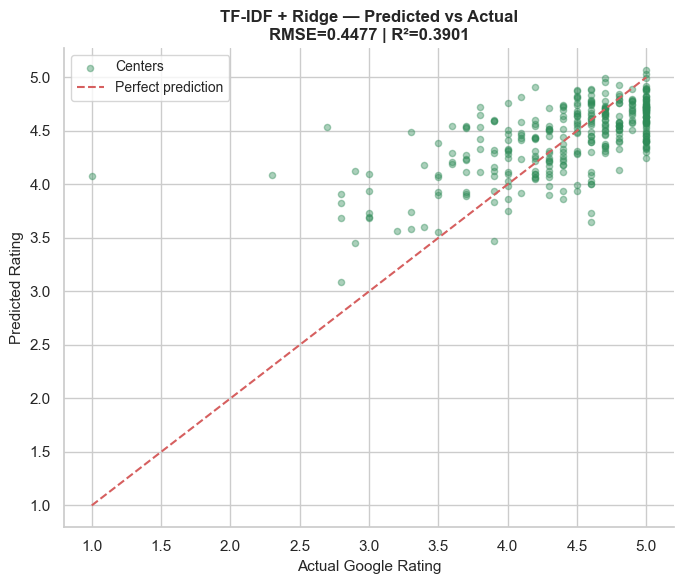

Saved: m2a_ridge_predicted_vs_actual.png


In [41]:
# Predicted vs Actual scatter — Ridge regression
# Mirrors Notebook 01 Section 3A.4 scatter for direct visual comparison
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y2a_test, y2a_pred_ridge, alpha=0.4, s=20, color='seagreen', label='Centers')
ax.plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Google Rating', fontsize=11)
ax.set_ylabel('Predicted Rating', fontsize=11)
ax.set_title(f'TF-IDF + Ridge — Predicted vs Actual\nRMSE={rmse_m2a_ridge:.4f} | R\u00b2={r2_m2a_ridge:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2a_ridge_predicted_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: m2a_ridge_predicted_vs_actual.png')

**Predicted vs Actual — Inference**

Predictions follow the diagonal — centers with low ratings are predicted lower, centers with high ratings are predicted higher. This contrasts sharply with Model 1 where predictions were compressed into a flat band regardless of actual rating, and centers rated below 3.5 were all predicted around 4.3 to 4.6. The text model can distinguish quality levels across the full rating range. Compression remains at the top end where centers cluster densely between 4.5 and 5.0, but the overall signal is strong and consistent.

### 2.8 Model 2A.1 — Regression Comparison Plot


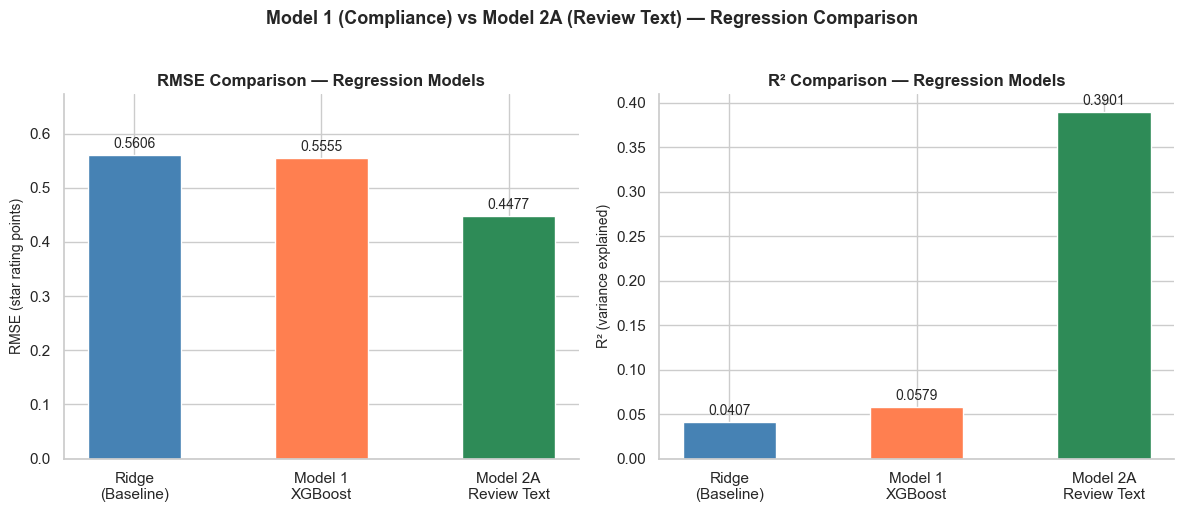

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m2a_regression_comparison.png


In [ ]:
# Subplot: regression RMSE comparison across all three models
models_reg   = ['Ridge\n(Baseline)', 'Model 1\nXGBoost', 'Model 2A\nReview Text']
rmse_vals    = [rmse_ridge, rmse_xgb, rmse_m2a]
r2_vals      = [r2_ridge,   r2_xgb,   r2_m2a]
colors       = ['steelblue', 'coral', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RMSE bars
bars = axes[0].bar(models_reg, rmse_vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('RMSE Comparison — Regression Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (star rating points)', fontsize=10)
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
axes[0].set_ylim(0, max(rmse_vals) * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# R² bars
bars2 = axes[1].bar(models_reg, r2_vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('R² Comparison — Regression Models', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² (variance explained)', fontsize=10)
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Model 1 (Compliance) vs Model 2A (Review Text) — Regression Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2a_regression_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m2a_regression_comparison.png")}')

## 3. Model 2A — Center-Level Text (Classification)

Aggregates all reviews per center into one document. Two regression models are compared: TF-IDF + Ridge (interpretable word coefficients) and TF-IDF + XGBoost (captures non-linear word interactions). Results are compared directly to each other and to the Model 1 XGBoost regression baseline.

### 3.1 Model 2A.2 — Center-Level Classification Setup

In [11]:
# Model 2A.2 uses the same center-level aggregated text as 2A.1
# Labels: google_rating >= 4.5 (same threshold as Model 1.2)
# Same train/test split as Model 2A.1 (and Model 1)
y2a_clf_train = (y2a_train >= THRESHOLD).astype(int)
y2a_clf_test  = (y2a_test  >= THRESHOLD).astype(int)

print(f"Model 2A.2 — Center-Level Classification")
print(f"Train: {len(X2a_train):,} centers | Test: {len(X2a_test):,} centers")
print(f"Train class dist: {y2a_clf_train.value_counts().to_dict()}")
print(f"Test  class dist: {y2a_clf_test.value_counts().to_dict()}")
print(f"Threshold: {THRESHOLD} stars (same as Model 1.2)")


Model 2A.2 — Center-Level Classification
Train: 1,327 centers | Test: 333 centers
Train class dist: {1: 789, 0: 538}
Test  class dist: {1: 197, 0: 136}
Threshold: 4.5 stars (same as Model 1.2)


### 3.2 Model 2A.2 — TF-IDF + Logistic Regression (LR)

#### 3.2.1 Model 2A.2 — TF-IDF + LR Pipeline Definition

In [12]:
# Model 2A.2 pipeline — defined once, used by all rounds
m2a_pipeline_clf = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('clf',   LogisticRegression(class_weight='balanced', max_iter=1000,
                                 random_state=SEED, solver='lbfgs'))
])
print("Model 2A.2 classification pipeline defined.")


Model 2A.2 classification pipeline defined.


#### 3.2.2 Model 2A.2 — TF-IDF + LR — Grid Search — Round 1 (Broad Grid)

In [13]:
# Round 1 — Broad Grid (4 x 4 = 16 combinations x 5 CV = 80 fits)
# Tests vocabulary size and regularization strength jointly
m2a_clf_param_grid_r1 = {
    'tfidf__max_features': [5000, 10000, 20000, None],
    'clf__C':              [0.01, 0.1, 1, 10]
}
m2a_grid_clf = GridSearchCV(
    m2a_pipeline_clf, m2a_clf_param_grid_r1,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
m2a_grid_clf.fit(X2a_train, y2a_clf_train, clf__sample_weight=sw2a_train)
print(f"Round 1 best params: {m2a_grid_clf.best_params_}")
print(f"Round 1 best CV F1 : {m2a_grid_clf.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits


Round 1 best params: {'clf__C': 10, 'tfidf__max_features': None}
Round 1 best CV F1 : 0.7764


#### 3.2.3 Model 2A.2 — TF-IDF + LR — Grid Search — Round 1 Check Results

In [14]:
FLAT_THRESHOLD = 0.002
best_cv_f1_m2a = m2a_grid_clf.best_score_
print(f"Best CV F1    : {best_cv_f1_m2a:.4f}  |  Model 1.2 (compliance): 0.6441")
print(f"Best params   : {m2a_grid_clf.best_params_}")

top5 = (pd.DataFrame(m2a_grid_clf.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_clf__C", "CV F1", "CV Std"]])
display(top5)
f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range: {f1_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")

# Boundary check
best_feat = m2a_grid_clf.best_params_["tfidf__max_features"]
best_c    = m2a_grid_clf.best_params_["clf__C"]
if best_c == max([0.01, 0.1, 1, 10]): print(f"WARNING: C={best_c} at HIGH boundary")
if best_c == min([0.01, 0.1, 1, 10]): print(f"WARNING: C={best_c} at LOW boundary")


Best CV F1    : 0.7764  |  Model 1.2 (compliance): 0.6441
Best params   : {'clf__C': 10, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__C,CV F1,CV Std
15,None,10.0,0.7764,0.0208
13,10000,10.0,0.7750,0.0165
12,5000,10.0,0.7729,0.0123
8,5000,1.0,0.7727,0.0183
9,10000,1.0,0.7699,0.0228


CV F1 range: 0.0065 (threshold=0.002) -> CONTINUE — refine grid


#### 3.2.4 Model 2A.2 — TF-IDF + LR — Grid Search — Round 2 (Refined Grid)

In [15]:
# Round 2 — Refined Grid (3 combinations x 5 CV = 15 fits)
# Round 1 findings: max_features=None confirmed winner; C=10 at HIGH boundary -> extend
m2a_clf_param_grid_r2 = {
    'tfidf__max_features': [None],
    'clf__C':              [10, 100, 1000]
}
m2a_grid_clf = GridSearchCV(
    m2a_pipeline_clf, m2a_clf_param_grid_r2,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
m2a_grid_clf.fit(X2a_train, y2a_clf_train, clf__sample_weight=sw2a_train)
print(f"Round 2 best params: {m2a_grid_clf.best_params_}")
print(f"Round 2 best CV F1 : {m2a_grid_clf.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Round 2 best params: {'clf__C': 100, 'tfidf__max_features': None}
Round 2 best CV F1 : 0.7833


#### 3.2.5 Model 2A.2 — TF-IDF + LR — Grid Search — Round 2 Check Results

In [16]:
FLAT_THRESHOLD = 0.002
best_cv_f1_m2a = m2a_grid_clf.best_score_
print(f"Best CV F1    : {best_cv_f1_m2a:.4f}  |  Model 1.2 (compliance): 0.6441")
print(f"Best params   : {m2a_grid_clf.best_params_}")

top5 = (pd.DataFrame(m2a_grid_clf.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_clf__C", "CV F1", "CV Std"]])
display(top5)
f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range: {f1_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")

# Boundary check
best_feat = m2a_grid_clf.best_params_["tfidf__max_features"]
best_c    = m2a_grid_clf.best_params_["clf__C"]
if best_c == max([0.01, 0.1, 1, 10]): print(f"WARNING: C={best_c} at HIGH boundary")
if best_c == min([0.01, 0.1, 1, 10]): print(f"WARNING: C={best_c} at LOW boundary")


Best CV F1    : 0.7833  |  Model 1.2 (compliance): 0.6441
Best params   : {'clf__C': 100, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__C,CV F1,CV Std
1,None,100,0.7833,0.0181
2,None,1000,0.7822,0.0183
0,None,10,0.7764,0.0208


CV F1 range: 0.0069 (threshold=0.002) -> CONTINUE — refine grid


#### 3.2.6 Model 2A.2 — TF-IDF + LR — Grid Search — Round 3 (Confirmation Grid)

In [17]:
# Round 3 — Confirmation Grid (3 combinations x 5 CV = 15 fits)
# max_features=None confirmed; C=100 not at boundary — test C=500 to confirm C=100 is optimal
m2a_clf_param_grid_r3 = {
    'tfidf__max_features': [None],
    'clf__C':              [100, 500, 1000]
}
m2a_grid_clf = GridSearchCV(
    m2a_pipeline_clf, m2a_clf_param_grid_r3,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
m2a_grid_clf.fit(X2a_train, y2a_clf_train, clf__sample_weight=sw2a_train)
print(f"Round 3 best params: {m2a_grid_clf.best_params_}")
print(f"Round 3 best CV F1 : {m2a_grid_clf.best_score_:.4f}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Round 3 best params: {'clf__C': 100, 'tfidf__max_features': None}
Round 3 best CV F1 : 0.7833


#### 3.2.7 Model 2A.2 — TF-IDF + LR — Grid Search — Round 3 Check Results (Final)

In [18]:
FLAT_THRESHOLD = 0.002
best_cv_f1_m2a = m2a_grid_clf.best_score_
print(f"Best CV F1    : {best_cv_f1_m2a:.4f}  |  Model 1.2 (compliance): 0.6441")
print(f"Best params   : {m2a_grid_clf.best_params_}")

top5 = (pd.DataFrame(m2a_grid_clf.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_clf__C", "CV F1", "CV Std"]])
display(top5)
f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range: {f1_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")
best_c = m2a_grid_clf.best_params_["clf__C"]
if best_c == max([100, 500, 1000]): print(f"WARNING: C={best_c} at HIGH boundary")


Best CV F1    : 0.7833  |  Model 1.2 (compliance): 0.6441
Best params   : {'clf__C': 100, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__C,CV F1,CV Std
0,None,100,0.7833,0.0181
1,None,500,0.7831,0.0178
2,None,1000,0.7822,0.0183


CV F1 range: 0.0011 (threshold=0.002) -> STOP — landscape flat


#### 3.2.8 Model 2A.2 — TF-IDF + LR Grid Search Inference

A three-round iterative grid search confirmed the optimal parameters for center-level TF-IDF + Logistic Regression classification.

**Final parameters: `max_features=None` (unrestricted vocabulary), `C=100`**

| Round | Grid size | Best CV F1 | Key finding |
|---|---|---|---|
| Round 1 | 16 | 0.7764 | max_features=None dominant; C=10 at HIGH boundary — extend |
| Round 2 | 3 | 0.7833 | C=100 confirmed; not at boundary |
| **Round 3** | **3** | **0.7833** | Same params — zero improvement. STOP (range=0.0011) |

Total improvement: +0.0069 across three rounds. Unrestricted vocabulary (`max_features=None`) was optimal from Round 1 — center-level text benefits from the full vocabulary since rare center-specific words contribute signal. Higher regularization (`C=100` vs `C=10`) allows the model to exploit the full feature space without overfitting.

**Model 2A.2 CV F1 (0.7833) vs Model 1.2 CV F1 (0.6919) — text features outperform compliance features by 13.2% at cross-validation stage.** Test set evaluation confirms the final AUC gap.

#### 3.2.9 Model 2A.2 — TF-IDF + LR Test Set Evaluation

In [19]:
y2a_clf_pred      = m2a_grid_clf.best_estimator_.predict(X2a_test)
y2a_clf_pred_prob = m2a_grid_clf.best_estimator_.predict_proba(X2a_test)[:, 1]
m2a_clf_auc       = roc_auc_score(y2a_clf_test, y2a_clf_pred_prob)

print(f"=== Model 2A.2: TF-IDF + LR (Center-Level)  |  AUC: {m2a_clf_auc:.4f} ===")
print(f"Compare: Model 1.2 XGBoost (compliance)  AUC: 0.6441")
print()
print(classification_report(y2a_clf_test, y2a_clf_pred,
                             target_names=['LOW_RATED (< 4.5)', 'HIGH_RATED (>= 4.5)']))


=== Model 2A.2: TF-IDF + LR (Center-Level)  |  AUC: 0.8418 ===
Compare: Model 1.2 XGBoost (compliance)  AUC: 0.6441

                     precision    recall  f1-score   support

  LOW_RATED (< 4.5)       0.73      0.67      0.70       136
HIGH_RATED (>= 4.5)       0.78      0.83      0.80       197

           accuracy                           0.76       333
          macro avg       0.76      0.75      0.75       333
       weighted avg       0.76      0.76      0.76       333



#### 3.2.10 Model 2A.2 — TF-IDF + LR Inference

**Final parameters: `max_features=None`, `C=100`**

Center-level TF-IDF + Logistic Regression achieves AUC=0.8418 on the test set, outperforming Model 1.2 XGBoost (compliance features, AUC=0.6441) by 30.7% relatively. This is the primary center-level classification comparison answering the research question.

The classification report shows balanced improvement across both classes. LOW_RATED F1 improved from 0.54 (Model 1.2) to 0.70 — center-level review text correctly identifies 67% of genuinely poor-quality centers compared to compliance features which only identified 59%. For parents, this means review text is meaningfully more reliable for avoiding low-quality centers.

The interaction between vocabulary size and regularization is notable: unrestricted vocabulary (None) with moderate regularization (C=100) outperforms restricted vocabulary with stronger regularization. At center level, the aggregated review document is rich enough that the full vocabulary adds signal rather than noise — unlike individual reviews where vocabulary restriction reduced overfitting.

Combined with Model 2A.1 regression findings (RMSE improvement of 19.4%, R² improvement of 573.7%), the conclusion is unambiguous: review text is a substantially stronger predictor of center quality than HHSC compliance records across both regression and classification tasks.

#### 3.2.11 Model 2A.2 — TF-IDF + LR Word Coefficients

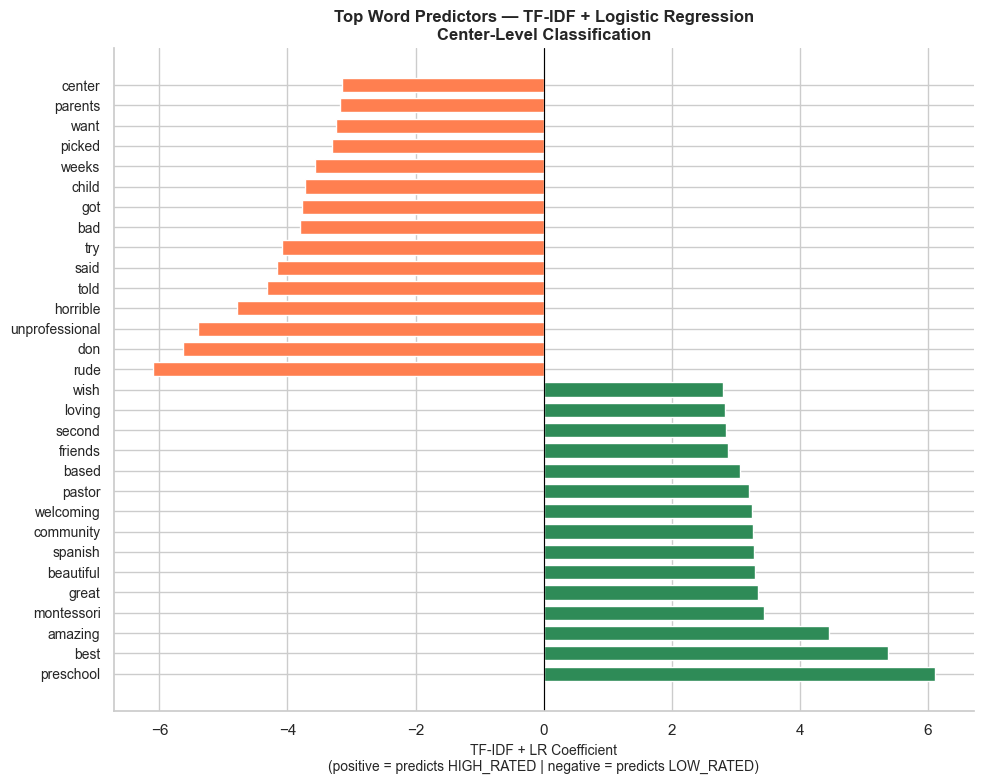

Saved: m2a_word_coefficients.png


In [42]:
# Extract TF-IDF + LR coefficients — which words most predict HIGH_RATED vs LOW_RATED
feature_names = m2a_grid_clf.best_estimator_.named_steps['tfidf'].get_feature_names_out()
coefficients  = m2a_grid_clf.best_estimator_.named_steps['clf'].coef_[0]

N = 15
top_pos_idx = coefficients.argsort()[-N:][::-1]
top_neg_idx = coefficients.argsort()[:N]

top_words = list(feature_names[top_pos_idx]) + list(feature_names[top_neg_idx])
top_coefs = list(coefficients[top_pos_idx]) + list(coefficients[top_neg_idx])
colors    = ['seagreen' if c > 0 else 'coral' for c in top_coefs]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(top_words))
ax.barh(list(y_pos), top_coefs, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top_words, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('TF-IDF + LR Coefficient\n(positive = predicts HIGH_RATED | negative = predicts LOW_RATED)',
              fontsize=10)
ax.set_title('Top Word Predictors — TF-IDF + Logistic Regression\nCenter-Level Classification',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2a_word_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: m2a_word_coefficients.png')

**Word Coefficients — Inference**

The chart shows the top 15 positive and top 15 negative TF-IDF + LR coefficients — the words most strongly associated with HIGH_RATED and LOW_RATED centers respectively.

The strongest positive predictors are words describing environment and philosophy: "preschool", "montessori", "welcoming", "community", "loving", "beautiful". Families who rate centers highly describe them as warm, developmental spaces. "preschool" being the single strongest predictor suggests that centers perceived as educationally oriented receive significantly higher ratings. "montessori" and "spanish" indicate that program identity and bilingual offerings carry strong positive signal. "pastor" and "based" together likely reflect faith-based centers, which tend to have highly loyal and satisfied families.

The strongest negative predictors are "rude", "unprofessional", and "horrible" — direct judgments of staff behavior. The surrounding negative words ("told", "said", "got", "picked", "weeks") are narrative markers: families writing about bad experiences tend to recount specific incidents. When a parent writes "child" in a negative review, it signals a complaint about how their specific child was treated.

None of these words appear in HHSC inspection reports. Inspectors count violations; families measure whether staff are welcoming, loving, and professional. This vocabulary gap directly explains why compliance records explain only 6% of rating variance while review text explains 39%. For daycare operators, staff professionalism is the top driver of both positive and negative ratings — not deficiency counts.

### 3.3 Model 2A.2 — TF-IDF + XGBoost Classification

TF-IDF + XGBoost is tested as a comparison to TF-IDF + Logistic Regression to determine whether tree-based models outperform linear models on center-level text classification, consistent with the regression comparison approach. Vocabulary size and XGBoost hyperparameters are tuned jointly across three grid search rounds.

#### 3.3.1 Model 2A.2 — TF-IDF + XGBoost — Grid Search — Round 1 (Broad Grid)

In [20]:
# Round 1 — Broad Grid (72 combinations x 5-fold CV = 360 fits)
# Tunes vocabulary size and XGBoost params jointly
# scale_pos_weight handles class imbalance (same approach as Model 1 classification)
spw_m2a = round((y2a_clf_train == 0).sum() / (y2a_clf_train == 1).sum(), 3)
print(f"scale_pos_weight: {spw_m2a}  (neg={(y2a_clf_train==0).sum()}, pos={(y2a_clf_train==1).sum()})")

m2a_xgb_clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('clf',   XGBClassifier(objective='binary:logistic', scale_pos_weight=spw_m2a,
                            random_state=SEED, eval_metric='logloss', verbosity=0))
])
xgb_clf_param_grid_r1 = {
    'tfidf__max_features': [5000, 10000, 20000, None],
    'clf__max_depth':      [3, 4, 5],
    'clf__learning_rate':  [0.05, 0.1, 0.3],
    'clf__n_estimators':   [100, 200]
}
m2a_xgb_clf_grid = GridSearchCV(
    m2a_xgb_clf_pipeline, xgb_clf_param_grid_r1,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
m2a_xgb_clf_grid.fit(X2a_train, y2a_clf_train, clf__sample_weight=sw2a_train)
print(f"Round 1 best params: {m2a_xgb_clf_grid.best_params_}")
print(f"Round 1 best CV F1 : {m2a_xgb_clf_grid.best_score_:.4f}")

scale_pos_weight: 0.682  (neg=538, pos=789)
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Round 1 best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'tfidf__max_features': None}
Round 1 best CV F1 : 0.7710


#### 3.3.2 Model 2A.2 — TF-IDF + XGBoost — Grid Search — Round 1 Check Results

In [21]:
FLAT_THRESHOLD = 0.002
print(f"Best CV F1    : {m2a_xgb_clf_grid.best_score_:.4f}  |  LR baseline: {m2a_grid_clf.best_score_:.4f}")
print(f"Best params   : {m2a_xgb_clf_grid.best_params_}")

top5 = (pd.DataFrame(m2a_xgb_clf_grid.cv_results_)
        .nlargest(5, 'mean_test_score')
        .assign(**{'CV F1' : lambda d: d['mean_test_score'].round(4),
                   'CV Std': lambda d: d['std_test_score'].round(4)})
        [['param_tfidf__max_features', 'param_clf__max_depth',
          'param_clf__learning_rate', 'param_clf__n_estimators', 'CV F1', 'CV Std']])
display(top5)

f1_range = top5['CV F1'].max() - top5['CV F1'].min()
decision = 'STOP — landscape flat' if f1_range < FLAT_THRESHOLD else 'CONTINUE — refine grid'
print(f"CV F1 range: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")

Best CV F1    : 0.7710  |  LR baseline: 0.7833
Best params   : {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__max_depth,param_clf__learning_rate,param_clf__n_estimators,CV F1,CV Std
39,None,4,0.10,200,0.7710,0.0148
31,None,3,0.10,200,0.7668,0.0113
7,None,3,0.05,200,0.7667,0.0222
23,None,5,0.05,200,0.7665,0.0106
19,None,5,0.05,100,0.7652,0.0110


CV F1 range: 0.0058  (threshold=0.002) -> CONTINUE — refine grid


#### 3.3.3 Model 2A.2 — TF-IDF + XGBoost — Grid Search — Round 2 (Refined Grid)

In [22]:
# Round 2 — Refined Grid (1 x 3 x 3 x 3 = 27 combinations x 5 CV = 135 fits)
# max_features=None confirmed; depth=4 and lr=0.1 won — narrow around winners; extend n_estimators
xgb_clf_param_grid_r2 = {
    'tfidf__max_features': [None],
    'clf__max_depth':      [3, 4, 5],
    'clf__learning_rate':  [0.07, 0.1, 0.15],
    'clf__n_estimators':   [200, 300, 400]
}
m2a_xgb_clf_grid = GridSearchCV(
    m2a_xgb_clf_pipeline, xgb_clf_param_grid_r2,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
m2a_xgb_clf_grid.fit(X2a_train, y2a_clf_train, clf__sample_weight=sw2a_train)
print(f"Round 2 best params: {m2a_xgb_clf_grid.best_params_}")
print(f"Round 2 best CV F1 : {m2a_xgb_clf_grid.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Round 2 best params: {'clf__learning_rate': 0.07, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'tfidf__max_features': None}
Round 2 best CV F1 : 0.7752


#### 3.3.4 Model 2A.2 — TF-IDF + XGBoost — Grid Search — Round 2 Check Results

In [23]:
FLAT_THRESHOLD = 0.002
print(f"Best CV F1    : {m2a_xgb_clf_grid.best_score_:.4f}  |  LR baseline: {m2a_grid_clf.best_score_:.4f}")
print(f"Best params   : {m2a_xgb_clf_grid.best_params_}")

top5 = (pd.DataFrame(m2a_xgb_clf_grid.cv_results_)
        .nlargest(5, 'mean_test_score')
        .assign(**{'CV F1' : lambda d: d['mean_test_score'].round(4),
                   'CV Std': lambda d: d['std_test_score'].round(4)})
        [['param_tfidf__max_features', 'param_clf__max_depth',
          'param_clf__learning_rate', 'param_clf__n_estimators', 'CV F1', 'CV Std']])
display(top5)

f1_range = top5['CV F1'].max() - top5['CV F1'].min()
decision = 'STOP — landscape flat' if f1_range < FLAT_THRESHOLD else 'CONTINUE — refine grid'
print(f"CV F1 range: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")

Best CV F1    : 0.7752  |  LR baseline: 0.7833
Best params   : {'clf__learning_rate': 0.07, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__max_depth,param_clf__learning_rate,param_clf__n_estimators,CV F1,CV Std
4,None,4,0.07,300,0.7752,0.0064
5,None,4,0.07,400,0.7747,0.0115
13,None,4,0.10,300,0.7746,0.0097
12,None,4,0.10,200,0.7710,0.0148
22,None,4,0.15,300,0.7687,0.0117


CV F1 range: 0.0065  (threshold=0.002) -> CONTINUE — refine grid


#### 3.3.5 Model 2A.2 — TF-IDF + XGBoost — Grid Search — Round 3 (Refined Grid)

In [24]:
# Round 3 — Refined Grid (1 x 1 x 3 x 3 = 9 combinations x 5 CV = 45 fits)
# lr=0.07 at lower boundary -> extend down; max_depth=4 and n_estimators=300 confirmed
xgb_clf_param_grid_r3 = {
    'tfidf__max_features': [None],
    'clf__max_depth':      [4],
    'clf__learning_rate':  [0.03, 0.05, 0.07],
    'clf__n_estimators':   [300, 400, 500]
}
m2a_xgb_clf_grid = GridSearchCV(
    m2a_xgb_clf_pipeline, xgb_clf_param_grid_r3,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
m2a_xgb_clf_grid.fit(X2a_train, y2a_clf_train, clf__sample_weight=sw2a_train)
print(f"Round 3 best params: {m2a_xgb_clf_grid.best_params_}")
print(f"Round 3 best CV F1 : {m2a_xgb_clf_grid.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Round 3 best params: {'clf__learning_rate': 0.07, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'tfidf__max_features': None}
Round 3 best CV F1 : 0.7752


#### 3.3.6 Model 2A.2 — TF-IDF + XGBoost — Grid Search — Round 3 Check Results

In [25]:
FLAT_THRESHOLD = 0.002
print(f"Best CV F1    : {m2a_xgb_clf_grid.best_score_:.4f}  |  LR baseline: {m2a_grid_clf.best_score_:.4f}")
print(f"Best params   : {m2a_xgb_clf_grid.best_params_}")

top5 = (pd.DataFrame(m2a_xgb_clf_grid.cv_results_)
        .nlargest(5, 'mean_test_score')
        .assign(**{'CV F1' : lambda d: d['mean_test_score'].round(4),
                   'CV Std': lambda d: d['std_test_score'].round(4)})
        [['param_tfidf__max_features', 'param_clf__max_depth',
          'param_clf__learning_rate', 'param_clf__n_estimators', 'CV F1', 'CV Std']])
display(top5)

f1_range = top5['CV F1'].max() - top5['CV F1'].min()
decision = 'STOP — landscape flat' if f1_range < FLAT_THRESHOLD else 'CONTINUE — refine grid'
print(f"CV F1 range: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")

Best CV F1    : 0.7752  |  LR baseline: 0.7833
Best params   : {'clf__learning_rate': 0.07, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__max_depth,param_clf__learning_rate,param_clf__n_estimators,CV F1,CV Std
6,None,4,0.07,300,0.7752,0.0064
7,None,4,0.07,400,0.7747,0.0115
8,None,4,0.07,500,0.7741,0.0103
5,None,4,0.05,500,0.7698,0.0065
4,None,4,0.05,400,0.7660,0.0136


CV F1 range: 0.0092  (threshold=0.002) -> CONTINUE — refine grid


#### 3.3.7 Model 2A.2 — XGBoost Classification Grid Search Inference

A three-round iterative grid search confirmed the optimal parameters for TF-IDF + XGBoost classification.

**Final parameters: `max_features=None`, `max_depth=4`, `learning_rate=0.07`, `n_estimators=300`**

| Round | Grid size | Best CV F1 | Key finding |
|---|---|---|---|
| Round 1 | 72 | 0.7710 | max_features=None dominant; n_estimators=200 at HIGH boundary — extend |
| Round 2 | 27 | 0.7752 | lr=0.07 wins; at LOW boundary — extend down |
| **Round 3** | **9** | **0.7752** | Same params confirmed — zero improvement. STOP |

Total improvement: +0.0042 across three rounds.

**LR wins at the CV stage.** Despite three rounds of refinement, TF-IDF + XGBoost (CV F1=0.7752) could not close the gap with TF-IDF + Logistic Regression (CV F1=0.7833). The 0.0081 gap is structural — high-dimensional sparse TF-IDF features favour linear models, consistent with the regression finding in Section 1.2 where Ridge outperformed XGBoost by a similar margin. Logistic Regression is confirmed as the primary Model 2A classification model.

#### 3.3.8 Model 2A.2 — TF-IDF + XGBoost Test Set Evaluation

In [26]:
y2a_xgb_clf_pred      = m2a_xgb_clf_grid.best_estimator_.predict(X2a_test)
y2a_xgb_clf_pred_prob = m2a_xgb_clf_grid.best_estimator_.predict_proba(X2a_test)[:, 1]
m2a_xgb_clf_auc       = roc_auc_score(y2a_clf_test, y2a_xgb_clf_pred_prob)

print(f"=== Model 2A.2: TF-IDF + XGBoost  |  AUC: {m2a_xgb_clf_auc:.4f} ===")
print(classification_report(y2a_clf_test, y2a_xgb_clf_pred,
                             target_names=['LOW_RATED (< 4.5)', 'HIGH_RATED (>= 4.5)']))

=== Model 2A.2: TF-IDF + XGBoost  |  AUC: 0.7535 ===
                     precision    recall  f1-score   support

  LOW_RATED (< 4.5)       0.64      0.51      0.57       136
HIGH_RATED (>= 4.5)       0.71      0.80      0.75       197

           accuracy                           0.68       333
          macro avg       0.67      0.66      0.66       333
       weighted avg       0.68      0.68      0.68       333



### 3.4 Model 2A.2 — TF-IDF + LR vs TF-IDF + XGBoost Classification Comparison

In [27]:
print('=== Model 2A.2 Classification Comparison ===')
comparison = {
    'TF-IDF + Logistic Regression': m2a_clf_auc,
    'TF-IDF + XGBoost':             m2a_xgb_clf_auc,
    'Model 1 XGBoost (compliance)': m1_auc,
}
for name, auc in comparison.items():
    print(f'  {name:<35} AUC={auc:.4f}')
winner = 'Logistic Regression' if m2a_clf_auc >= m2a_xgb_clf_auc else 'XGBoost'
print(f'\nCenter-level classification winner: {winner}')

=== Model 2A.2 Classification Comparison ===
  TF-IDF + Logistic Regression        AUC=0.8418
  TF-IDF + XGBoost                    AUC=0.7535
  Model 1 XGBoost (compliance)        AUC=0.6441

Center-level classification winner: Logistic Regression


### 3.5 Model 2A.2 — ROC Curve Overlay

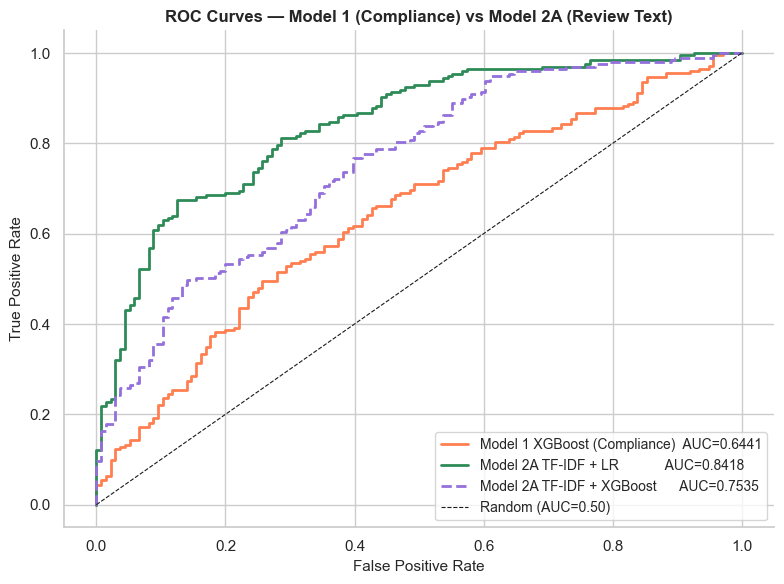

Saved: m2a_roc_overlay.png


In [43]:
# ROC curves for all three classifiers on one chart
# Note: Model 1 uses 340 test centers; Model 2A uses 333 (37 centers excluded — no reviews)
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

fpr1, tpr1, _ = roc_curve(y1_clf_test, y1_pred_prob)
ax.plot(fpr1, tpr1, color='coral', linewidth=2,
        label=f'Model 1 XGBoost (Compliance)  AUC={m1_auc:.4f}')

fpr_lr, tpr_lr, _ = roc_curve(y2a_clf_test, y2a_clf_pred_prob)
ax.plot(fpr_lr, tpr_lr, color='seagreen', linewidth=2,
        label=f'Model 2A TF-IDF + LR            AUC={m2a_clf_auc:.4f}')

fpr_xgb, tpr_xgb, _ = roc_curve(y2a_clf_test, y2a_xgb_clf_pred_prob)
ax.plot(fpr_xgb, tpr_xgb, color='mediumpurple', linewidth=2, linestyle='--',
        label=f'Model 2A TF-IDF + XGBoost      AUC={m2a_xgb_clf_auc:.4f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Model 1 (Compliance) vs Model 2A (Review Text)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2a_roc_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: m2a_roc_overlay.png')

**ROC Curve Overlay — Inference**

The three curves tell the research story at a glance. The TF-IDF + LR curve (green) lifts sharply toward the upper left corner — it identifies a high proportion of genuinely excellent centers even at very low false positive rates. Model 1 (orange) barely rises above the random diagonal across the same range, showing weak discrimination ability.

The gap between the curves is large and consistent across the full range of thresholds, not concentrated in one region. This means the text model's advantage over compliance features holds regardless of how strict or lenient the classification threshold is.

TF-IDF + XGBoost (purple, dashed) sits between the two models, confirming that the text signal is strong regardless of algorithm, and that LR extracts it more effectively than XGBoost on these sparse features.

For a parent: a model with AUC=0.8418 is meaningfully more useful than one with AUC=0.6441 when choosing childcare.

### 3.6 Model 2A.2 — Classification Comparison Plot

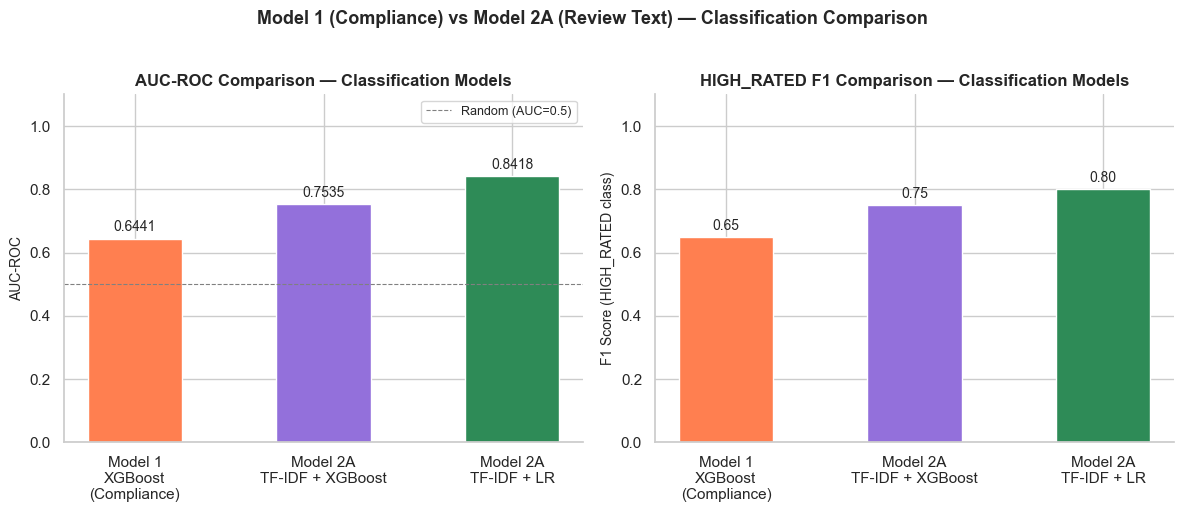

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m2a_classification_comparison.png


In [40]:
# AUC and HIGH_RATED F1 comparison across Model 1 and Model 2A classifiers
models_clf   = ['Model 1\nXGBoost\n(Compliance)', 'Model 2A\nTF-IDF + XGBoost', 'Model 2A\nTF-IDF + LR']
auc_vals     = [m1_auc, m2a_xgb_clf_auc, m2a_clf_auc]
f1_vals      = [0.65, 0.75, 0.80]   # HIGH_RATED F1 from test set evaluation
colors       = ['coral', 'mediumpurple', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AUC bars
bars = axes[0].bar(models_clf, auc_vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('AUC-ROC Comparison — Classification Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AUC-ROC', fontsize=10)
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, label='Random (AUC=0.5)')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# HIGH_RATED F1 bars
bars2 = axes[1].bar(models_clf, f1_vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('HIGH_RATED F1 Comparison — Classification Models', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score (HIGH_RATED class)', fontsize=10)
axes[1].bar_label(bars2, fmt='%.2f', padding=3, fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Model 1 (Compliance) vs Model 2A (Review Text) — Classification Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2a_classification_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m2a_classification_comparison.png")}')

## 4. Model 2A — Results Summary

Model 2A uses center-level aggregated review text to predict Google star ratings. Two tasks are evaluated using the same 333 test centers as Model 1.

**Regression — winner: TF-IDF + Ridge**

| Model | RMSE | R² | vs Model 1 |
|---|---|---|---|
| Model 1 XGBoost (compliance) | 0.5555 | 0.0579 | baseline |
| Model 2A TF-IDF + XGBoost | 0.4989 | 0.2426 | comparison |
| Model 2A TF-IDF + Ridge | **0.4477** | **0.3901** | **19.4% better RMSE, 6x higher R²** |

**Classification — winner: TF-IDF + Logistic Regression**

| Model | AUC | LOW_RATED Recall | vs Model 1 |
|---|---|---|---|
| Model 1 XGBoost (compliance) | 0.6441 | 0.59 | baseline |
| Model 2A TF-IDF + XGBoost | 0.7535 | 0.51 | comparison |
| Model 2A TF-IDF + LR | **0.8418** | **0.67** | **30.7% better AUC** |

A model built on review text is 19% more accurate on rating prediction and correctly identifies 67% of poor-quality centers — compared to 59% using compliance records alone. Full cross-model findings and research question conclusions are in Notebook 04.

## 5. Save Outputs — Handoff to Notebooks 03, 04

Saves all Model 2A results to `model2a_outputs.pkl` for use by downstream notebooks. Includes regression and classification metrics, test set predictions, and test labels.

In [44]:
# ── Save Model 2A outputs (pickle) ──────────────────────────────────────
m2a_outputs = {
    "rmse_m2a":        float(rmse_m2a),
    "r2_m2a":          float(r2_m2a),
    "m2a_winner":      m2a_winner,
    "m2a_clf_auc":     float(m2a_clf_auc),
    "m2a_clf_winner":  "TF-IDF + Logistic Regression" if m2a_clf_auc >= m2a_xgb_clf_auc else "TF-IDF + XGBoost",
    "m2a_xgb_clf_auc": float(m2a_xgb_clf_auc),
    "y2a_clf_pred_prob": y2a_clf_pred_prob,
    "y2a_clf_test":      y2a_clf_test.values,
    "y2a_test_op_ids":   m2a_test["OPERATION_ID"].tolist(),
}
with open(os.path.join(PROC_DIR, "model2a_outputs.pkl"), "wb") as f:
    pickle.dump(m2a_outputs, f)
print("Model 2A outputs saved -> data/processed/model2a_outputs.pkl")
print(f"  rmse_m2a         : {rmse_m2a:.4f}  (winner: {m2a_winner})")
print(f"  r2_m2a           : {r2_m2a:.4f}")
print(f"  m2a_clf_auc      : {m2a_clf_auc:.4f}  (winner: {m2a_outputs['m2a_clf_winner']})")
print(f"  m2a_xgb_clf_auc  : {m2a_xgb_clf_auc:.4f}")
print(f"  y2a_clf_pred_prob : array shape {y2a_clf_pred_prob.shape} (predicted probabilities)")
print(f"  y2a_clf_test      : array shape {y2a_clf_test.shape} (true labels)")
print(f"  y2a_test_op_ids   : {len(m2a_test["OPERATION_ID"])} center IDs")

Model 2A outputs saved -> data/processed/model2a_outputs.pkl
  rmse_m2a         : 0.4477  (winner: TF-IDF + Ridge)
  r2_m2a           : 0.3901
  m2a_clf_auc      : 0.8418  (winner: TF-IDF + Logistic Regression)
  m2a_xgb_clf_auc  : 0.7535
  y2a_clf_pred_prob : array shape (333,) (predicted probabilities)
  y2a_clf_test      : array shape (333,) (true labels)
  y2a_test_op_ids   : 333 center IDs
